In [ ]:
%uv pip install einops

In [ ]:
%uv pip install datasets

In [ ]:
%uv pip install levenshtein

In [ ]:
%uv pip install sentence-transformers==2.7.0

In [ ]:
%uv pip install nltk

In [ ]:
%uv pip install transformers

In [8]:
import matplotlib.pyplot as plt
import numpy as np

P_PARAMETER = 0.9

def compute_np_discoverable_extraction(secret_prob, p=P_PARAMETER):
    if secret_prob <= 0:
        return np.inf
    if secret_prob >= 1:
        return 1
    num = np.log2(1 - p)
    den = np.log2(1 - secret_prob)
    return np.ceil(num / den)

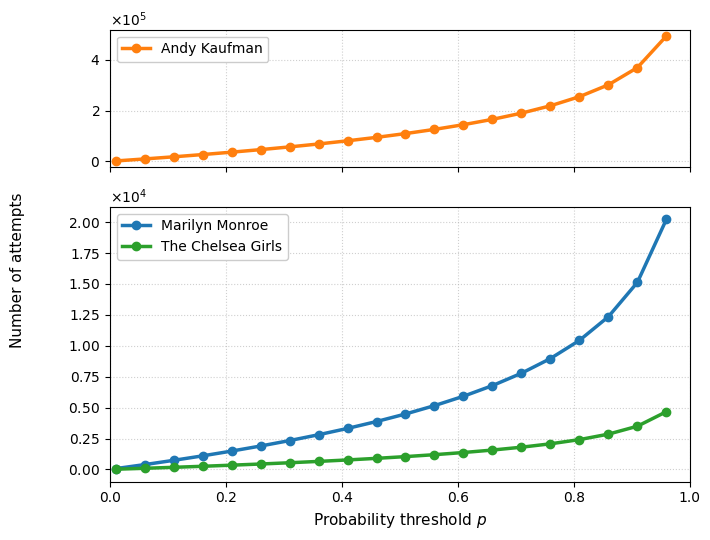

In [28]:
import matplotlib.ticker as ticker


def plot_attempts_vs_p(attempts_by_suffix, save_path='attempts_vs_p.pdf'):
    highlight_key = 'Andy Kaufman'
    
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_map = {key: colors[i % len(colors)] for i, key in enumerate(attempts_by_suffix.keys())}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.2, 3.8), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 2]})

    # Top panel
    for key, entries in attempts_by_suffix.items():
        if key != highlight_key:
            continue
        ps       = [e[0] for e in entries]
        attempts = [np.ceil(e[1]) for e in entries]
        ax1.plot(ps, attempts, marker='o', linestyle='-', linewidth=2.5,
                 markersize=6, label=key, color=color_map.get(key, 'C0'))

    ax1.legend(loc='upper left', framealpha=1)
    ax1.grid(True, linestyle=':', alpha=0.6, which='major')

    formatter1 = ticker.ScalarFormatter(useMathText=True)
    formatter1.set_powerlimits((-3, 4))
    ax1.yaxis.set_major_formatter(formatter1)

    # Bottom panel
    for key, entries in attempts_by_suffix.items():
        if key == highlight_key:
            continue
        ps       = [e[0] for e in entries]
        attempts = [np.ceil(e[1]) for e in entries]
        ax2.plot(ps, attempts, marker='o', linestyle='-', linewidth=2.5,
                 markersize=6, label=key, color=color_map.get(key, 'C0'))

    ax2.set_xlabel('Probability threshold $p$', fontsize=11)
    ax2.legend(loc='upper left', framealpha=1)
    ax2.grid(True, linestyle=':', alpha=0.6, which='major')
    ax2.set_xlim(0, 1)

    formatter2 = ticker.ScalarFormatter(useMathText=True)
    formatter2.set_powerlimits((-3, 4))
    ax2.yaxis.set_major_formatter(formatter2)

    fig.text(0.02, 0.5, 'Number of attempts', va='center',
             rotation='vertical', fontsize=11)

 
    plt.tight_layout(rect=[0.08, 0, 1, 1])
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_attempts_vs_p(attempts_by_suffix)

## VaultGemma

In [ ]:
!hf auth login --token <TOKEN>

In [9]:
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("google/vaultgemma-1b")
samples_max_length = 100
context_len = 50 #len in tokens


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.95M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

In [10]:
def split_tokens(sequence, tokenizer, prefix_token_length=50):
    tokens = tokenizer.encode(sequence)
    return tokenizer.decode(tokens[:prefix_token_length]) , tokenizer.decode(tokens[prefix_token_length:])

In [11]:
from datasets import load_dataset
def generate_commonCrawl_sequences(amount=1000, random_seed=42, max_tokens=100):
    """
    Samplea aleatoriamente `amount` ejemplos del dataset C4 (Common Crawl en inglés)
    truncando cada texto a exactamente `max_tokens` tokens.
    
    Returns:
        list of dicts con keys: 'text', 'timestamp', 'url', 'tokens'
    """
    cc_en = load_dataset(
        "allenai/c4",
        "en",
        split="train",
        streaming=True
    )
    
    cc_en_shuffled = cc_en.shuffle(
        seed=random_seed,
        buffer_size=10_000
    )
    
    samples = []
    for example in cc_en_shuffled:
        if len(samples) >= amount:
            break

        tokens = tokenizer.encode(example["text"])

        if len(tokens) < max_tokens:
            continue

        tokens_truncated = tokens[:max_tokens]
        text_truncated = tokenizer.decode(tokens_truncated, skip_special_tokens=True)

        samples.append({
            "text": text_truncated,
            "timestamp": example["timestamp"],
            "url": example["url"],
            "tokens": tokens_truncated,
            "token_count": len(tokens_truncated)
        })
    
    print(f"Sampled {len(samples)} examples of C4")
    return samples



sequences = generate_commonCrawl_sequences(amount=50, random_seed=1, max_tokens=55)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Sampled 50 examples of C4


Using top-5 masking

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]

results = dict()
for seq in tqdm(sequences):
    prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
    secrets_list = [suffix]
    
    print("Secret is ", suffix)
    print("Context is ", prefix)
    _, _, target_prob_list, generated_suffixes = compute_renyi_divergence_alpha_and_ranking(
    sequences=secrets_list,
    model_name=model_name,
    secrets_paired_to_context = secrets_list,
    alpha=1,
    context=prefix,
    KL=True,
    topk=True,
    k=5,
    depth=5,
    allow_filler_tokens=True,
    distance_metric="jaro-winkler",
    distance_threshold=0.8)

    if not target_prob_list:
        prob_target = 0
    else:
        prob_target = target_prob_list[0] #Only one sequence paired to prefix
        
    results[prefix] = (suffix, prob_target)

In [12]:
def calculate_average_prob(result, total_seqs=100):
    sum_prob = 0
    for prefix in list(results.keys()):
        generated_suffix, suffix_prob = results[prefix]
        sum_prob += suffix_prob
    
    return sum_prob/total_seqs


In [48]:
average_prob_per_theta = list()

jaro_winkler_average_prob = calculate_average_prob(results)

average_prob_per_theta.append(("jaro-winkler", jaro_winkler_average_prob))

In [1]:
average_prob_per_theta = [('jaro-winkler', 0.11473769816543777),
 ('exact', 0.0004047710957817609),
 ('supersequence', 0.0004041503190909429),
 ('approximate', 0.00567809365329043),
 ('bleu', 0.002739657597376944),
 ('subsequence', 0.0004041503190909429)]

Now calculating the average prob with the rest of theta functions

In [11]:
%uv pip install sentence-transformers transformers

#Required for nomic-ai/nomic-embed-text-v1

Using Python 3.12.6 environment at: /usr/local
Audited 2 packages in 26ms


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


for theta in ["cosine"]: #"subsequence","exact", "supersequence", "approximate", "bleu"]: #Jaro-winkler already calculated
    results = dict()
    for seq in tqdm(sequences):
        prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
        secrets_list = [suffix]
        
        print("Secret is ", suffix)
        print("Context is ", prefix)
        _, _, target_prob_list, generated_suffixes  = compute_renyi_divergence_alpha_and_ranking(
        sequences=secrets_list,
        model_name=model_name,
        secrets_paired_to_context = secrets_list,
        alpha=1,
        context=prefix,
        KL=True,
        topk=True,
        k=5,
        depth=5,
        allow_filler_tokens=True,
        distance_metric=theta,
        distance_threshold=0.8)

        if not target_prob_list:
            prob_target = 0
        else:
            prob_target = target_prob_list[0] #Only one sequence paired to prefix
            
        results[prefix] = (suffix, prob_target)

        
    average_prob_per_theta.append((theta,calculate_average_prob(results)))

In [11]:
average_prob_per_theta

[('jaro-winkler', 0.11473769816543777),
 ('exact', 0.0004047710957817609),
 ('supersequence', 0.0004041503190909429),
 ('approximate', 0.00567809365329043),
 ('bleu', 0.002739657597376944),
 ('subsequence', 0.0004041503190909429),
 ('cosine', 0.01622025240150534)]

In [2]:
average_prob_per_theta=[('jaro-winkler', 0.11473769816543777),
 ('exact', 0.0004047710957817609),
 ('supersequence', 0.0004041503190909429),
 ('approximate', 0.00567809365329043),
 ('bleu', 0.002739657597376944),
 ('subsequence', 0.0004041503190909429),
 ('cosine', 0.01622025240150534)]

In [5]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

p_values = np.arange(0.01, 1.0, 0.05) 

attempts_by_theta_gemma_noTemp = defaultdict(list)

for theta, avg_prob in average_prob_per_theta:
    for p in p_values:
        val = compute_np_discoverable_extraction(avg_prob, p=p)
        attempts_by_theta_gemma_noTemp[theta].append((p, val))

In [13]:
attempts_by_theta_gemma_noTemp

defaultdict(list,
            {'jaro-winkler': [(np.float64(0.01),
               np.float64(0.08246680345087597)),
              (np.float64(0.060000000000000005),
               np.float64(0.5077110686888537)),
              (np.float64(0.11), np.float64(0.9562039976218255)),
              (np.float64(0.16000000000000003), np.float64(1.430635425347858)),
              (np.float64(0.21000000000000002), np.float64(1.934190820169599)),
              (np.float64(0.26), np.float64(2.470681066446)),
              (np.float64(0.31000000000000005),
               np.float64(3.0447177215829346)),
              (np.float64(0.36000000000000004), np.float64(3.661954317904376)),
              (np.float64(0.41000000000000003), np.float64(4.32942602812566)),
              (np.float64(0.46), np.float64(5.056040115446937)),
              (np.float64(0.51), np.float64(5.853305387282181)),
              (np.float64(0.56), np.float64(6.736455657941717)),
              (np.float64(0.6100000000000001), np

Gemma 2B

In [13]:
average_prob_per_theta_gemma = list()

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


for theta in ["subsequence","exact", "supersequence",  "approximate", "bleu"]:  #"jaro-winkler", 
    results = dict()
    for seq in tqdm(sequences):
        prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
        secrets_list = [suffix]
        
        print("Secret is ", suffix)
        print("Context is ", prefix)
        _, _, target_prob_list, generated_suffixes  = compute_renyi_divergence_alpha_and_ranking(
        sequences=secrets_list,
        model_name=model_name,
        secrets_paired_to_context = secrets_list,
        alpha=1,
        context=prefix,
        KL=True,
        topk=True,
        k=5,
        depth=5,
        allow_filler_tokens=True,
        distance_metric=theta,
        distance_threshold=0.8)

        if not target_prob_list:
            prob_target = 0
        else:
            prob_target = target_prob_list[0] #Only one sequence paired to prefix
            
        results[prefix] = (suffix, prob_target)

        
    average_prob_per_theta_gemma.append((theta,calculate_average_prob(results)))

In [24]:
average_prob_per_theta_gemma = [('jaro-winkler', 0.1851489617549344),
 ('subsequence', 0.00876019832573164),
 ('exact', 0.008276428774936943),
 ('supersequence', 0.00883844180152486),
 ('approximate', 0.023017448138558712),
 ('bleu', 0.014070743114453318)]

[('jaro-winkler', 0.1851489617549344),
 ('subsequence', 0.00876019832573164),
 ('exact', 0.008276428774936943),
 ('supersequence', 0.00883844180152486),
 ('approximate', 0.023017448138558712),
 ('bleu', 0.014070743114453318)]

### Using top-5 masking and temperature scaling T=0.5

In [6]:
average_prob_per_theta_with_temp = list()

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


for theta in ["subsequence", "jaro-winkler", "exact", "supersequence", "approximate", "bleu"]: #["cosine"]
    results = dict()
    for seq in tqdm(sequences):
        prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
        secrets_list = [suffix]
        
        print("Secret is ", suffix)
        print("Context is ", prefix)
        _, _, target_prob_list, generated_suffixes  = compute_renyi_divergence_alpha_and_ranking(
        sequences=secrets_list,
        model_name=model_name,
        secrets_paired_to_context = secrets_list,
        alpha=1,
        context=prefix,
        KL=True,
        topk=True,
        k=5,
        depth=5,
        allow_filler_tokens=True,
        distance_metric=theta,
        distance_threshold=0.8,
        temperature=0.5)

        if not target_prob_list:
            prob_target = 0
        else:
            prob_target = target_prob_list[0] #Only one sequence paired to prefix
            
        results[prefix] = (suffix, prob_target)

        
    average_prob_per_theta_with_temp.append((theta,calculate_average_prob(results)))

In [ ]:
average_prob_per_theta_with_temp

[('subsequence', 0.0010934224485083443),
 ('jaro-winkler', 0.14056927564338706),
 ('exact', 0.0010805732948538642),
 ('supersequence', 0.0010934224485083443),
 ('approximate', 0.01034058347114366),
 ('bleu', 0.005839512972440668)]

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


for theta in ["cosine"]: 
    results = dict()
    for seq in tqdm(sequences):
        prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
        secrets_list = [suffix]
        
        print("Secret is ", suffix)
        print("Context is ", prefix)
        _, _, target_prob_list, generated_suffixes  = compute_renyi_divergence_alpha_and_ranking(
        sequences=secrets_list,
        model_name=model_name,
        secrets_paired_to_context = secrets_list,
        alpha=1,
        context=prefix,
        KL=True,
        topk=True,
        k=5,
        depth=5,
        allow_filler_tokens=True,
        distance_metric=theta,
        distance_threshold=0.8,
        temperature=0.5)

        if not target_prob_list:
            prob_target = 0
        else:
            prob_target = target_prob_list[0] #Only one sequence paired to prefix
            
        results[prefix] = (suffix, prob_target)

        
    average_prob_per_theta_with_temp.append((theta,calculate_average_prob(results)))

In [8]:
average_prob_per_theta_with_temp

[('cosine', 0.02414232363127952)]

In [6]:
average_prob_per_theta_with_temp = [('subsequence', 0.0010934224485083443),
 ('jaro-winkler', 0.14056927564338706),
 ('exact', 0.0010805732948538642),
 ('supersequence', 0.0010934224485083443),
 ('approximate', 0.01034058347114366),
 ('bleu', 0.005839512972440668),
 ('cosine', 0.02414232363127952)]

In [7]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

p_values = np.arange(0.01, 1.0, 0.05) 

attempts_by_theta_gemma_Temp = defaultdict(list)

for theta, avg_prob in average_prob_per_theta_with_temp:
    for p in p_values:
        val = compute_np_discoverable_extraction(avg_prob, p=p)
        attempts_by_theta_gemma_Temp[theta].append((p, val))

In [34]:
attempts_by_theta_gemma_noTemp['exact']

[(np.float64(0.01), np.float64(24.82465220032255)),
 (np.float64(0.060000000000000005), np.float64(152.83423354662585)),
 (np.float64(0.11), np.float64(287.8422671937302)),
 (np.float64(0.16000000000000003), np.float64(430.6584634491959)),
 (np.float64(0.21000000000000002), np.float64(582.2417311029762)),
 (np.float64(0.26), np.float64(743.7392454404934)),
 (np.float64(0.31000000000000005), np.float64(916.539205153974)),
 (np.float64(0.36000000000000004), np.float64(1102.3434704801805)),
 (np.float64(0.41000000000000003), np.float64(1303.26981134009)),
 (np.float64(0.46), np.float64(1521.9995455700628)),
 (np.float64(0.51), np.float64(1761.9971234620589)),
 (np.float64(0.56), np.float64(2027.8483192441702)),
 (np.float64(0.6100000000000001), np.float64(2325.803321557237)),
 (np.float64(0.66), np.float64(2664.6944962118473)),
 (np.float64(0.7100000000000001), np.float64(3057.589398341591)),
 (np.float64(0.76), np.float64(3525.0232126139103)),
 (np.float64(0.81), np.float64(4102.05939468

Gemma 2

In [13]:
average_prob_per_theta_withTemp_gemma = list()

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


for theta in ["jaro-winkler", "subsequence","exact", "supersequence",  "approximate", "bleu"]: 
    results = dict()
    for seq in tqdm(sequences):
        prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
        secrets_list = [suffix]
        
        _, _, target_prob_list, generated_suffixes  = compute_renyi_divergence_alpha_and_ranking(
        sequences=secrets_list,
        model_name=model_name,
        secrets_paired_to_context = secrets_list,
        alpha=1,
        context=prefix,
        KL=True,
        topk=True,
        k=5,
        depth=5,
        allow_filler_tokens=True,
        distance_metric=theta,
        distance_threshold=0.8,
        temperature=0.5)

        if not target_prob_list:
            prob_target = 0
        else:
            prob_target = target_prob_list[0] #Only one sequence paired to prefix
            
        results[prefix] = (suffix, prob_target)

        
    average_prob_per_theta_withTemp_gemma.append((theta,calculate_average_prob(results)))

In [ ]:
average_prob_per_theta_withTemp_gemma

# VaultGemma confidence intervals

The procedure is the following:

- Obtain the generated sequences for each prefix.
- Calculate the similarity of every sequence to its target.
- Sum the probability of all the similar sequences for each target for a specific theta.
- Repeat previous step for all thetas.

# Vaultgemma without temperature scaling

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


results = dict()
for seq in tqdm(sequences):
    prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
    secrets_list = [suffix]
    
    print("Secret is ", suffix)
    print("Context is ", prefix)
    _, _, _, generated_probs = compute_renyi_divergence_alpha_and_ranking(
    sequences=secrets_list,
    model_name=model_name,
    secrets_paired_to_context = secrets_list,
    alpha=1,
    context=prefix,
    KL=True,
    topk=True,
    k=5,
    depth=5,
    allow_filler_tokens=True,
    distance_metric="approximate",
    distance_threshold=0)

    results[prefix] = generated_probs

In [16]:
import pickle


with open("sequences_vaultgemma_notempscaling.pkl", "wb") as f:
    pickle.dump(results, f)

In [4]:
import pickle


with open("sequences_vaultgemma_notempscaling.pkl", "rb") as f:
    sequences_prob_vaultgemma_notemp = pickle.load(f)

In [ ]:
from tqdm import tqdm
from probability_utils import cosine_similarity, levenshtein_similarity, bleu_score, contains_ordered_tokens, jaro_winkler_similarity
from sentence_transformers import SentenceTransformer


sentence_encoder = SentenceTransformer("nomic-ai/nomic-embed-text-v1", trust_remote_code=True)


def calculate_similarities(sequences_probs):
    count = 0
    sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
    sequences = [seq["text"] for seq in sequences]
    results = dict()
    prefixes = list(sequences_probs.keys())
    for sequence in tqdm(sequences):
        similarities_per_suffix = list()
        prefix, target_suffix = split_tokens(sequence, tokenizer, prefix_token_length=50)
        
        list_seqs_probs = sequences_probs[prefix]

        if not list_seqs_probs:
            count+=1
            continue
            
        emb_target = sentence_encoder.encode(target_suffix)

        for item_generated_suffix_prob in list_seqs_probs:
            generated_suffix = item_generated_suffix_prob['decoded']
            prob = item_generated_suffix_prob['prob']
            
            jaro_winkler_sim = jaro_winkler_similarity(target_suffix, generated_suffix)
            levenshtein_sim = levenshtein_similarity(target_suffix, generated_suffix)

            cosine_sim = 0
            if jaro_winkler_sim > 0.75: #Cosine is computationally expensive, only calculated when it is appropriate
                emb_generated = sentence_encoder.encode(generated_suffix)
                cosine_sim = cosine_similarity(emb_target, emb_generated)
            bleu_sim = bleu_score(target_suffix, generated_suffix)
            superseq_sim=0
            
            subseq_sim=0

            exact_sim = 0
            if target_suffix == generated_suffix:
                exact_sim= 1
            if target_suffix in generated_suffix:
                subseq_sim=1
            if contains_ordered_tokens(target_suffix, generated_suffix):
                superseq_sim=1
            similarities_per_suffix.append((generated_suffix, prob, cosine_sim, jaro_winkler_sim, levenshtein_sim, bleu_sim, superseq_sim, subseq_sim, exact_sim))
            
        results[prefix] = similarities_per_suffix
    print("Skipped", count)
    return results

In [ ]:
sim_vaultgemma = calculate_similarities(sequences_prob_vaultgemma_notemp)

In [13]:
import numpy as np
theta_mapping = {
    "cosine":0,
    "jaro-winkler":1,
    "levenshtein":2,
    "bleu":3,
    "supersequence":4,
    "subsequence":5,
    "exact":6
}
def get_probabilities_above_threshold(similarities, threshold=0.8, theta="supersequence"):
    prefixes = list(similarities.keys())
    suffixes_probabilities = list()
    for prefix in prefixes:
        sum_prob_target_suffix = 0
        list_similarities_per_suffix = similarities[prefix]
        for item in list_similarities_per_suffix:
            generated_suffix, prob, cosine_sim, jaro_winkler_sim, levenshtein_sim, bleu_sim, superseq_sim, subseq_sim, exact_sim = item
            list_similarities = [cosine_sim, jaro_winkler_sim, levenshtein_sim, bleu_sim, superseq_sim, subseq_sim, exact_sim]
            theta_index = theta_mapping.get(theta, None)
            similarity_value = list_similarities[theta_index]
            if similarity_value >= threshold:
                sum_prob_target_suffix+=prob
        suffixes_probabilities.append(sum_prob_target_suffix)
    return suffixes_probabilities
                
            

In [41]:
import pickle


probs_per_theta = {
"cosine":  get_probabilities_above_threshold(sim_vaultgemma, theta="cosine"),
"supersequence" : get_probabilities_above_threshold(sim_vaultgemma, theta="supersequence"),
"levenshtein": get_probabilities_above_threshold(sim_vaultgemma, theta="levenshtein"),
"jaro-winkler": get_probabilities_above_threshold(sim_vaultgemma, theta="jaro-winkler"),
"exact": get_probabilities_above_threshold(sim_vaultgemma, theta="exact")
}


with open("probs_per_theta.pkl", "wb") as f:
    pickle.dump(probs_per_theta, f)

In [48]:
print(np.array(probs_per_theta['jaro-winkler']).mean())
print(np.array(probs_per_theta['supersequence']).mean())
print(np.array(probs_per_theta['levenshtein']).mean())
print(np.array(probs_per_theta['exact']).mean())

0.11473769816543776
0.0004041503190909429
0.005678093653290432
0.0004041503190909429


In [49]:
import pickle


with open("probs_per_theta_vaultgemma_notempscaling.pkl", "wb") as f:
    pickle.dump(probs_per_theta, f)

## VaultGemma with temperature scaling T=0.5

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


results = dict()
for seq in tqdm(sequences):
    prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
    secrets_list = [suffix]
    
    print("Secret is ", suffix)
    print("Context is ", prefix)
    _, _, _, generated_probs = compute_renyi_divergence_alpha_and_ranking(
    sequences=secrets_list,
    model_name=model_name,
    secrets_paired_to_context = secrets_list,
    alpha=1,
    context=prefix,
    KL=True,
    topk=True,
    k=5,
    depth=5,
    allow_filler_tokens=True,
    distance_metric="approximate",
    distance_threshold=0,
    temperature=0.5)

    results[prefix] = generated_probs

In [51]:
import pickle


with open("sequences_vaultgemma_withtempscaling.pkl", "wb") as f:
    pickle.dump(results, f)

In [52]:
import pickle


with open("sequences_vaultgemma_withtempscaling.pkl", "rb") as f:
    sequences_prob_vaultgemma_withtemp = pickle.load(f)

In [ ]:
sim_vaultgemma_withTemp = calculate_similarities(sequences_prob_vaultgemma_withtemp)

In [58]:
import pickle


probs_per_theta_with_temperature = {
"cosine":  get_probabilities_above_threshold(sim_vaultgemma_withTemp, theta="cosine"),
"supersequence" : get_probabilities_above_threshold(sim_vaultgemma_withTemp, theta="supersequence"),
"levenshtein": get_probabilities_above_threshold(sim_vaultgemma_withTemp, theta="levenshtein"),
"jaro-winkler": get_probabilities_above_threshold(sim_vaultgemma_withTemp, theta="jaro-winkler"),
"exact": get_probabilities_above_threshold(sim_vaultgemma_withTemp, theta="exact")
}


with open("probs_per_theta_with_temperature.pkl", "wb") as f:
    pickle.dump(probs_per_theta_with_temperature, f)

In [6]:
import pickle


with open("probs_per_theta_with_temperature.pkl", "rb") as f:
    probs_per_theta_with_temperature = pickle.load(f)

with open("probs_per_theta_vaultgemma_notempscaling.pkl", "rb") as f:
    probs_per_theta_vaultgemma_notempscaling = pickle.load(f)

In [10]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

p_values = np.arange(0.01, 1.0, 0.05) 

attempts_by_theta_gemma_Temp = defaultdict(list)
attempts_by_theta_gemma_noTemp = defaultdict(list)
thetas = list(probs_per_theta_vaultgemma_notempscaling.keys())
for theta in thetas:
    for p in p_values:
        attempts = list()
        for prob in probs_per_theta_vaultgemma_notempscaling[theta]:
            attempts.append(compute_np_discoverable_extraction(prob, p=p))
        attempts_by_theta_gemma_noTemp[theta].append((p, attempts))

for theta in thetas:
    for p in p_values:
        attempts = list()
        for prob in probs_per_theta_with_temperature[theta]:
            attempts.append(compute_np_discoverable_extraction(prob, p=p))
        attempts_by_theta_gemma_Temp[theta].append((p, attempts))

/tmp/ipykernel_214/3825913449.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  return num / den


In [39]:
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker


from matplotlib.ticker import FuncFormatter

def sci_formatter(x, pos):
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    if abs(coeff - 1.0) < 1e-9:
        return r'$10^{%d}$' % exp
    if abs(coeff - round(coeff)) < 1e-9:
        return r'$%d\times10^{%d}$' % (int(round(coeff)), exp)
    return r'$%.1f\times10^{%d}$' % (coeff, exp)
    
def plot_attempts_function_of_p(attempts_by_theta_gemma_noTemp, attempts_by_theta_gemma_Temp):
    fig, ax = plt.subplots(figsize=(7.2, 3.8))

    attempts_by_theta_t1 = attempts_by_theta_gemma_noTemp.copy()
    attempts_by_theta_t05 = attempts_by_theta_gemma_Temp.copy()

    attempts_by_theta_t1.pop("supersequence",None)
    attempts_by_theta_t1.pop("bleu",None)
    attempts_by_theta_t1.pop("subsequence",None)
    attempts_by_theta_t05.pop("supersequence",None)
    attempts_by_theta_t05.pop("bleu",None)
    attempts_by_theta_t05.pop("subsequence",None)

    theta_colors = {
        'jaro-winkler': 'C1',
        'cosine':       'C2',
        'levenshtein':  'C0',
        'bleu':         'C3',
        'supersequence':'C4',
        'subsequence':  'C5',
        'exact':        'C5',
    }
    display_names = {
        'levenshtein':  'Levenshtein',
        'exact':        'Verbatim',
        'cosine':       'Cosine',
        'jaro-winkler': 'Jaro-Winkler',
        'bleu':         'BLEU',
        'supersequence':'Supersequence',
        'subsequence':  'Subsequence',
    }

    for theta, entries in attempts_by_theta_t1.items():
        ps       = [e[0] for e in entries]
        attempts_min = [min(a for a in e[1] if np.isfinite(a) and a > 0) for e in entries]
        ax.plot(ps, attempts_min, marker='o', linestyle='-', linewidth=2.5,
                markersize=5, color=theta_colors.get(theta, 'black'))

    for theta, entries in attempts_by_theta_t05.items():
        ps       = [e[0] for e in entries]
        attempts_min = [min(a for a in e[1] if np.isfinite(a) and a > 0) for e in entries]
        ax.plot(ps, attempts_min, marker='o', linestyle=(0, (5, 5)), linewidth=2.5,
                markersize=5, color=theta_colors.get(theta, 'black'))

    legend_order = ['levenshtein', 'cosine', 'jaro-winkler', 'exact']
    metric_handles = [
        Line2D([0], [0], color=theta_colors.get(t, 'black'), linewidth=2.5,
               linestyle='-', label=display_names.get(t, t))
        for t in legend_order
    ]
    style_handles = [
        Line2D([0], [0], color='black', linewidth=2.5, linestyle='-',  label='VaultGemma (T=1)'),
        Line2D([0], [0], color='black', linewidth=2.5, linestyle=(0, (5, 5)), label='VaultGemma (T=0.5)'),
    ]

    ax.legend(handles=metric_handles + style_handles,
              loc='upper left', bbox_to_anchor=(1.02, 1),
              framealpha=1, borderaxespad=0, fontsize=11)
    fig.canvas.draw()
    legend_width = ax.get_legend().get_window_extent().width
    fig_width = fig.get_window_extent().width
    right_margin = 1 - (legend_width / fig_width) - 0.02
    fig.subplots_adjust(left=0.12, right=right_margin, top=0.95, bottom=0.15)

    ax.set_xlabel('Probability threshold $p$', fontsize=14)
    ax.set_ylabel('Minimum number of attempts', fontsize=14)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, linestyle=':', alpha=0.6, which='major')
    ax.set_yscale('log')

    ax.yaxis.set_major_formatter(FuncFormatter(sci_formatter))

    fig.set_size_inches(7.2, 3.8)
    plt.savefig('attempts_vs_p.pdf', dpi=600)
    plt.show()


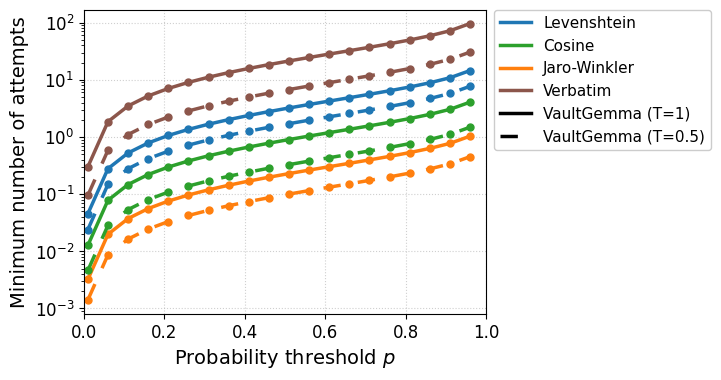

In [40]:

plot_attempts_function_of_p(attempts_by_theta_gemma_noTemp, attempts_by_theta_gemma_Temp)

## Confidence Intervals per theta

In [3]:
import numpy as np
import scipy.stats as stats

def mean_ci(probs, confidence=0.95):
    n = len(probs)
    mean = np.mean(probs)
    se = stats.sem(probs)
    ci_low, ci_high = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return mean, ci_low, ci_high

def paired_diff_ci(probs1, probs2, confidence=0.95):
    """CI for the mean difference of paired samples."""
    diffs = np.array(probs1) - np.array(probs2)
    n = len(diffs)
    mean_diff = np.mean(diffs)
    se = stats.sem(diffs)
    ci_low, ci_high = stats.t.interval(confidence, df=n-1, loc=mean_diff, scale=se)
    return mean_diff, ci_low, ci_high

thetas = ['cosine', 'levenshtein', 'jaro-winkler', 'exact', 'supersequence']

print(f"{'Theta':<15} {'Mean (T=1)':>12} {'CI (T=1)':>22} {'Mean (T=0.5)':>14} {'CI (T=0.5)':>22} {'Diff':>8} {'CI Diff':>22}")
print("-" * 120)
for theta in thetas:
    p1 = probs_per_theta_vaultgemma_notempscaling[theta]
    p2 = probs_per_theta_with_temperature[theta]
    m1, l1, u1 = mean_ci(p1)
    m2, l2, u2 = mean_ci(p2)
    diff, dl, du = paired_diff_ci(p1, p2)
    print(f"{theta:<15} {m1:>12.4f} [{l1:.4f}, {u1:.4f}]  {m2:>14.4f} [{l2:.4f}, {u2:.4f}]  {diff:>8.4f} [{dl:.4f}, {du:.4f}]")

Theta             Mean (T=1)               CI (T=1)   Mean (T=0.5)             CI (T=0.5)     Diff                CI Diff
------------------------------------------------------------------------------------------------------------------------
cosine                0.0144 [0.0014, 0.0274]          0.0218 [-0.0001, 0.0438]   -0.0074 [-0.0168, 0.0020]
levenshtein           0.0057 [0.0009, 0.0105]          0.0103 [0.0012, 0.0195]   -0.0047 [-0.0094, 0.0001]
jaro-winkler          0.1147 [0.0748, 0.1547]          0.1406 [0.0881, 0.1931]   -0.0258 [-0.0419, -0.0098]
exact                 0.0004 [-0.0003, 0.0011]          0.0011 [-0.0009, 0.0031]   -0.0007 [-0.0020, 0.0006]
supersequence         0.0004 [-0.0003, 0.0011]          0.0011 [-0.0009, 0.0031]   -0.0007 [-0.0020, 0.0006]


# VaultGemma with T=0.25 and T=0.125

In [15]:
%uv pip install --upgrade transformers

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Using Python 3.12.6 environment at: /usr/local
Resolved 27 packages in 334ms
⠙ Preparing packages... (0/22)
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------     0 B/5.18 KiB
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------     0 B/5.18 KiB
packaging  ------------------------------     0 B/126.91 KiB
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------     0 B/5.18 KiB
packaging  ------------------------------     0 B/126.91 KiB
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
packaging  ------------------------------     0 B/126.91 KiB
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
packaging  ------------------------------ 14.79 KiB/126.91 KiB
⠙ Preparing packages... (0/22)
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
tqdm       ------------------------------     0 B/78.32 KiB
packaging  --------------

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


results = dict()
for seq in tqdm(sequences):
    prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
    secrets_list = [suffix]
    
    print("Secret is ", suffix)
    print("Context is ", prefix)
    _, _, _, generated_probs = compute_renyi_divergence_alpha_and_ranking(
    sequences=secrets_list,
    model_name=model_name,
    secrets_paired_to_context = secrets_list,
    alpha=1,
    context=prefix,
    KL=True,
    topk=True,
    k=5,
    depth=5,
    allow_filler_tokens=True,
    distance_metric="approximate",
    distance_threshold=0,
    temperature=0.25)

    results[prefix] = generated_probs

In [15]:
import pickle


with open("sequences_vaultgemma_withtempscaling025.pkl", "wb") as f:
    pickle.dump(results, f)

In [13]:
%uv pip install sentence-transformers==2.7.0 transformers==4.40.0

Using Python 3.12.6 environment at: /usr/local
Resolved 46 packages in 259ms
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
huggingface-hub ------------------------------ 188.83 KiB/553.12 KiB
⠙ Preparing packages... (0/3)
huggingface-hub ------------------------------ 188.83 KiB/553.12 KiB
⠙ Preparing packages... (0/3)
huggingface-hub ------------------------------ 188.83 KiB/553.12 KiB
tokenizers ------------------------------ 14.84 KiB/3.44 MiB
⠙ Preparing packages... (0/3)
huggingface-hub ------------------------------ 204.83 KiB/553.12 KiB
tokenizers ------------------------------ 14.84 KiB/3.44 MiB
⠙ Preparing pac

In [10]:
import pickle


with open("sequences_vaultgemma_withtempscaling025.pkl", "rb") as f:
    sequences_prob_vaultgemma_withtemp = pickle.load(f)

In [ ]:
sim_vaultgemma_withTemp025 = calculate_similarities(sequences_prob_vaultgemma_withtemp)

In [21]:
import pickle


probs_per_theta_with_temperature025 = {
"cosine":  get_probabilities_above_threshold(sim_vaultgemma_withTemp025, theta="cosine"),
"levenshtein": get_probabilities_above_threshold(sim_vaultgemma_withTemp025, theta="levenshtein"),
"jaro-winkler": get_probabilities_above_threshold(sim_vaultgemma_withTemp025, theta="jaro-winkler"),
"exact": get_probabilities_above_threshold(sim_vaultgemma_withTemp025, theta="exact")
}


with open("probs_per_theta_with_temperature025.pkl", "wb") as f:
    pickle.dump(probs_per_theta_with_temperature025, f)

T = 0.125

In [ ]:
from transformers import AutoTokenizer
from probability_utils import generate_sequences,compute_renyi_divergence_alpha_and_ranking, calculate_exposure, compute_np_discoverable_extraction
from transformers import AutoTokenizer
from visualization_utils import plot_suffix_ranking
from tqdm import tqdm

model_name = "google/vaultgemma-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)


sequences = generate_commonCrawl_sequences(amount=100, random_seed=3, max_tokens=55)
sequences = [seq["text"] for seq in sequences]


results = dict()
for seq in tqdm(sequences):
    prefix, suffix = split_tokens(seq, tokenizer, prefix_token_length=50)
    secrets_list = [suffix]
    
    print("Secret is ", suffix)
    print("Context is ", prefix)
    _, _, _, generated_probs = compute_renyi_divergence_alpha_and_ranking(
    sequences=secrets_list,
    model_name=model_name,
    secrets_paired_to_context = secrets_list,
    alpha=1,
    context=prefix,
    KL=True,
    topk=True,
    k=5,
    depth=5,
    allow_filler_tokens=True,
    distance_metric="approximate",
    distance_threshold=0,
    temperature=0.125)

    results[prefix] = generated_probs

In [18]:
import pickle


with open("sequences_vaultgemma_withtempscaling0125.pkl", "wb") as f:
    pickle.dump(results, f)

In [14]:
import pickle


with open("sequences_vaultgemma_withtempscaling0125.pkl", "rb") as f:
    sequences_prob_vaultgemma_withtemp = pickle.load(f)

In [ ]:
sim_vaultgemma_withTemp0125 = calculate_similarities(sequences_prob_vaultgemma_withtemp)

In [ ]:
import pickle


probs_per_theta_with_temperature0125 = {
"cosine":  get_probabilities_above_threshold(sim_vaultgemma_withTemp0125, theta="cosine"),
"levenshtein": get_probabilities_above_threshold(sim_vaultgemma_withTemp0125, theta="levenshtein"),
"jaro-winkler": get_probabilities_above_threshold(sim_vaultgemma_withTemp0125, theta="jaro-winkler"),
"exact": get_probabilities_above_threshold(sim_vaultgemma_withTemp0125, theta="exact")
}


with open("probs_per_theta_with_temperature0125.pkl", "wb") as f:
    pickle.dump(probs_per_theta_with_temperature0125, f)

In [1]:
from statsmodels.stats.proportion import proportion_confint


def calculate_CI(probs_per_theta_with_temperature):
    for theta, probs in probs_per_theta_with_temperature0125.items():
        binary = [1 if p > 0 else 0 for p in probs]
        n = len(binary)
        k = sum(binary)
        rate = k / n * 100
        ci_low, ci_high = proportion_confint(k, n, method='beta')  # Clopper-Pearson
        print(f"{theta}: rate={rate:.2f}%  CP=({ci_low*100:.2f}%, {ci_high*100:.2f}%)")




In [5]:
import pickle

with open("probs_per_theta_with_temperature0125.pkl", "rb") as f:
    probs_per_theta_with_temperature0125 = pickle.load(f)

with open("probs_per_theta_with_temperature025.pkl", "rb") as f:
    probs_per_theta_with_temperature025 = pickle.load(f)


print("TEMPERATURE 0.25")
calculate_CI(probs_per_theta_with_temperature025)
print("TEMPERATURE 0.125")
calculate_CI(probs_per_theta_with_temperature0125)

TEMPERATURE 0.25
cosine: rate=30.00%  CP=(21.24%, 39.98%)
levenshtein: rate=17.00%  CP=(10.23%, 25.82%)
jaro-winkler: rate=62.00%  CP=(51.75%, 71.52%)
exact: rate=3.00%  CP=(0.62%, 8.52%)
TEMPERATURE 0.125
cosine: rate=30.00%  CP=(21.24%, 39.98%)
levenshtein: rate=17.00%  CP=(10.23%, 25.82%)
jaro-winkler: rate=62.00%  CP=(51.75%, 71.52%)
exact: rate=3.00%  CP=(0.62%, 8.52%)


# Attempt box-plot

In [2]:
import pickle

with open("probs_per_theta_with_temperature0125.pkl", "rb") as f:
    probs_per_theta_with_temperature0125 = pickle.load(f)

with open("probs_per_theta_with_temperature025.pkl", "rb") as f:
    probs_per_theta_with_temperature025 = pickle.load(f)

with open("probs_per_theta_with_temperature.pkl", "rb") as f:
    probs_per_theta_with_temperature = pickle.load(f)

with open("probs_per_theta_vaultgemma_notempscaling.pkl", "rb") as f:
    probs_per_theta_vaultgemma_notempscaling = pickle.load(f)

/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)
/tmp/ipykernel_88/3259570691.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True, flierprops=dict(marker='o', markersize=2, linestyle='none'))
/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)
/tmp/ipykernel_88/3259570691.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True, flierprops=dict(marker='o', markersize=2, linestyle='none'))
/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(n

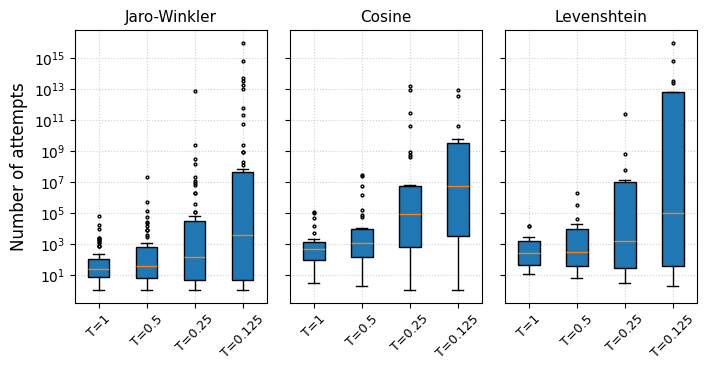

In [10]:
import matplotlib.pyplot as plt
import numpy as np

p_value = 0.9

# Dict of all temperature conditions
all_temps = {
    'T=1':     probs_per_theta_vaultgemma_notempscaling,
    'T=0.5':   probs_per_theta_with_temperature,
    'T=0.25':  probs_per_theta_with_temperature025,
    'T=0.125': probs_per_theta_with_temperature0125,
}

thetas = ['jaro-winkler', 'cosine', 'levenshtein']
display_names = {
    'jaro-winkler': 'Jaro-Winkler',
    'cosine':       'Cosine',
    'levenshtein':  'Levenshtein',
}

fig, axes = plt.subplots(1, len(thetas), figsize=(7.2, 3.8), sharey=True)

for ax, theta in zip(axes, thetas):
    data = []
    labels = []
    for temp_label, probs_dict in all_temps.items():
        probs = probs_dict[theta]
        attempts = [compute_np_discoverable_extraction(p, p=p_value)
                    for p in probs if p > 0 and np.isfinite(
                        compute_np_discoverable_extraction(p, p=p_value))]
        data.append(attempts)
        labels.append(temp_label)
    
    ax.boxplot(data, labels=labels, patch_artist=True, flierprops=dict(marker='o', markersize=2, linestyle='none'))
    ax.set_title(display_names[theta], fontsize=11)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_yscale('log')
    ax.grid(True, linestyle=':', alpha=0.6, which='major')

axes[0].set_ylabel('Number of attempts', fontsize=12)
plt.tight_layout()
fig.set_size_inches(7.2, 3.8)
plt.savefig('boxplot_attempts_temperature.pdf', dpi=600)
plt.show()

Confidence interval for the median

In [11]:
import numpy as np
from scipy import stats

def bootstrap_median_ci(data, n_bootstrap=10000, confidence=0.95):
    """Bootstrap CI for the median."""
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    boot_medians = [np.median(np.random.choice(data, size=len(data), replace=True))
                    for _ in range(n_bootstrap)]
    alpha = 1 - confidence
    ci_low  = np.percentile(boot_medians, 100 * alpha / 2)
    ci_high = np.percentile(boot_medians, 100 * (1 - alpha / 2))
    return np.median(data), ci_low, ci_high

# Usage
for temp_label, probs_dict in all_temps.items():
    for theta in thetas:
        probs = probs_dict[theta]
        attempts = [compute_np_discoverable_extraction(p) 
                    for p in probs if p > 0 and np.isfinite(
                        compute_np_discoverable_extraction(p))]
        median, ci_low, ci_high = bootstrap_median_ci(attempts)
        print(f"{temp_label} {theta}: median={median:.2f} [{ci_low:.2f}, {ci_high:.2f}]")

T=1 jaro-winkler: median=23.50 [16.00, 50.50]
T=1 cosine: median=467.00 [195.50, 1031.00]
T=1 levenshtein: median=277.00 [41.00, 1614.00]
T=0.5 jaro-winkler: median=40.50 [17.00, 101.00]
T=0.5 cosine: median=1237.50 [455.50, 5287.00]
T=0.5 levenshtein: median=289.00 [40.00, 9736.00]
T=0.25 jaro-winkler: median=142.00 [26.00, 1061.00]
T=0.25 cosine: median=82050.00 [4878.00, 371498.50]
T=0.25 levenshtein: median=1546.00 [28.00, 10384173.00]


/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)


T=0.125 jaro-winkler: median=3752.00 [47.00, 285368.00]
T=0.125 cosine: median=5879904.00 [63489.00, 3509664466.00]
T=0.125 levenshtein: median=100183.00 [38.00, 13228556662566.50]


## KS Test and survival curves

/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)


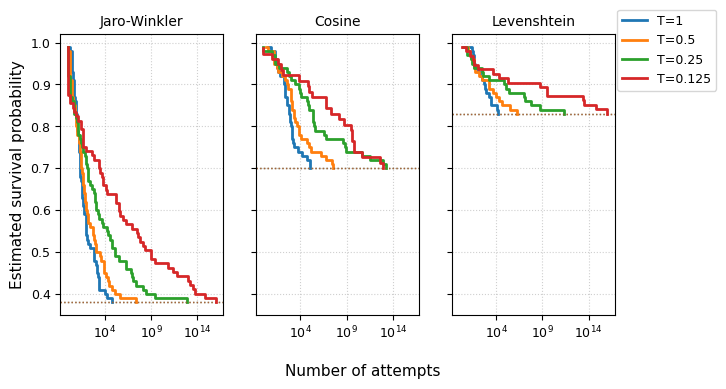


Metric          Comparison              KS stat      p-value  Significant
------------------------------------------------------------------------
Jaro-Winkler    T=1 vs T=0.5          1828.0000       0.6402             
Jaro-Winkler    T=1 vs T=0.25         1538.5000       0.0555             
Jaro-Winkler    T=1 vs T=0.125        1269.5000       0.0025            *

Cosine          T=1 vs T=0.5           346.0000       0.1259             
Cosine          T=1 vs T=0.25          230.5000       0.0012            *
Cosine          T=1 vs T=0.125         164.0000       0.0012            *

Levenshtein     T=1 vs T=0.5           134.0000       0.7305             
Levenshtein     T=1 vs T=0.25          115.5000       0.3262             
Levenshtein     T=1 vs T=0.125          90.0000       0.1012             



/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D

P_PARAMETER = 0.9

all_temps = {
    'T=1':     probs_per_theta_vaultgemma_notempscaling,
    'T=0.5':   probs_per_theta_with_temperature,
    'T=0.25':  probs_per_theta_with_temperature025,
    'T=0.125': probs_per_theta_with_temperature0125,
}

thetas = ['jaro-winkler', 'cosine', 'levenshtein']
display_names = {
    'jaro-winkler': 'Jaro-Winkler',
    'cosine':       'Cosine',
    'levenshtein':  'Levenshtein',
}
temp_colors = {
    'T=1':     'C0',
    'T=0.5':   'C1',
    'T=0.25':  'C2',
    'T=0.125': 'C3',
}

def get_attempts_with_inf(probs):
    """Returns finite attempts and the proportion of infinite (prob=0) cases."""
    n_total = len(probs)
    finite = np.array([compute_np_discoverable_extraction(p)
                       for p in probs if p > 0 and np.isfinite(
                           compute_np_discoverable_extraction(p))])
    n_infinite = sum(1 for p in probs if p == 0)
    prop_infinite = n_infinite / n_total
    return finite, prop_infinite

def get_attempts(probs):
    return np.array([compute_np_discoverable_extraction(p)
                     for p in probs if p > 0 and np.isfinite(
                         compute_np_discoverable_extraction(p))])

def survival_curve_with_inf(attempts, prop_infinite):
    """Survival curve shifted up by the proportion of infinite attempts."""
    sorted_attempts = np.sort(attempts)
    n = len(sorted_attempts)
    survival = prop_infinite + (1 - prop_infinite) * (1 - np.arange(1, n + 1) / n)
    return sorted_attempts, survival

# --- Survival curves ---
fig, axes = plt.subplots(1, len(thetas), figsize=(7.2, 3.8), sharey=True, sharex=True)

for ax, theta in zip(axes, thetas):
    for temp_label, probs_dict in all_temps.items():
        probs = probs_dict[theta]
        attempts, prop_infinite = get_attempts_with_inf(probs)
        if len(attempts) == 0:
            continue
        x, s = survival_curve_with_inf(attempts, prop_infinite)
        ax.step(x, s, where='post', linewidth=2,
                color=temp_colors[temp_label], label=temp_label)
        ax.axhline(y=prop_infinite, color=temp_colors[temp_label],
                   linestyle=':', linewidth=1, alpha=0.5)

    ax.set_title(display_names[theta], fontsize=10)
    ax.set_xscale('log')
    ax.tick_params(labelsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.text(0.5, 0.02, 'Number of attempts', ha='center', fontsize=11)
axes[0].set_ylabel('Estimated survival probability', fontsize=11)
temp_handles = [Line2D([0], [0], color=c, linewidth=2, label=t)
                for t, c in temp_colors.items()]
fig.legend(handles=temp_handles, loc='upper right', fontsize=9,
           bbox_to_anchor=(1.0, 1.0))
fig.subplots_adjust(left=0.08, right=0.85, top=0.92, bottom=0.18)
fig.set_size_inches(7.2, 3.8)
plt.savefig('survival_attempts_temperature.pdf', dpi=600)
plt.show()

# --- Kolmogorov-Smirnov tests ---
print(f"\n{'Metric':<15} {'Comparison':<20} {'KS stat':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 72)

temp_labels = list(all_temps.keys())
for theta in thetas:
    attempts_per_temp = {t: get_attempts(probs_dict[theta])
                         for t, probs_dict in all_temps.items()}
    for temp_label in temp_labels[1:]:
        a1 = attempts_per_temp['T=1']
        a2 = attempts_per_temp[temp_label]
        if len(a1) == 0 or len(a2) == 0:
            continue
        ks_stat, p_value = stats.mannwhitneyu(a1, a2)
        significant = '*' if p_value < 0.05 else ''
        print(f"{display_names[theta]:<15} {'T=1 vs ' + temp_label:<20} "
              f"{ks_stat:>10.4f} {p_value:>12.4f} {significant:>12}")
    print()

In [13]:
for temp_label, probs_dict in all_temps.items():
    print(f"\n{temp_label}:")
    for theta, probs in probs_dict.items():
        count = sum(1 for p in probs if p > 0)
        print(f"  {theta}: {count}/100")


T=1:
  cosine: 30/100
  supersequence: 3/100
  levenshtein: 17/100
  jaro-winkler: 62/100
  exact: 3/100

T=0.5:
  cosine: 30/100
  supersequence: 3/100
  levenshtein: 17/100
  jaro-winkler: 62/100
  exact: 3/100

T=0.25:
  cosine: 30/100
  levenshtein: 17/100
  jaro-winkler: 62/100
  exact: 3/100

T=0.125:
  cosine: 30/100
  levenshtein: 17/100
  jaro-winkler: 62/100
  exact: 3/100


## Bootstrap KS test

In [14]:
import numpy as np


def paired_global_ks(attempts, B=5000, seed=42):
    """
    Global paired KS test for equality of marginal
    distributions across temperatures.

    attempts: array (N, K)
        N responses evaluated at K temperatures.
        Values may include np.inf.

    B: number of bootstrap replications.

    Returns:
        D: global KS statistic
        p_value: bootstrap p-value
        F: empirical CDFs evaluated at observed values
        grid: finite observed values
    """

    X = np.asarray(attempts, dtype=float)

    if X.ndim != 2:
        raise ValueError("Expected an (N, K) array.")

    if np.isnan(X).any():
        raise ValueError("Missing values are not supported.")

    N, K = X.shape

    if N < 2 or K < 2:
        raise ValueError("Need N >= 2 and K >= 2.")

    # All distinct finite values observed
    grid = np.unique(X[np.isfinite(X)])

    if len(grid) == 0:
        return 0.0, 1.0, np.empty((0, K)), grid

    M = len(grid)

    # Precompute ranks for each temperature
    indices = []
    masks = []

    F = np.empty((M, K))

    for j in range(K):
        mask = np.isfinite(X[:, j])

        idx = np.searchsorted(
            grid, X[mask, j]
        )

        masks.append(mask)
        indices.append(idx)

        counts = np.bincount(
            idx, minlength=M
        )

        F[:, j] = np.cumsum(counts) / N

    # Global KS statistic:
    D = np.ptp(F, axis=1).max()

    # Multiplier bootstrap of the centered
    # empirical distribution processes
    rng = np.random.default_rng(seed)

    critical_statistics = np.empty(B)

    for b in range(B):
        # One weight per response, shared across
        # all temperatures since the sequences are the same
        w = rng.standard_normal(N)
        w_sum = w.sum()

        G = np.empty((M, K))

        for j in range(K):

            weighted_counts = np.bincount(
                indices[j],
                weights=w[masks[j]],
                minlength=M
            )

            weighted_cdf = np.cumsum(
                weighted_counts
            )

            G[:, j] = (
                weighted_cdf - F[:, j] * w_sum
            ) / np.sqrt(N)

        critical_statistics[b] = (
            np.ptp(G, axis=1).max()
        )

    observed = np.sqrt(N) * D

    p_value = (
        1 + np.sum(critical_statistics >= observed)
    ) / (B + 1)

    return D, p_value, F, grid

In [20]:
import numpy as np

def get_attempts_for_ks(probs):
    """Returns attempts including inf for zero probabilities."""
    return np.array([
        compute_np_discoverable_extraction(p) if p > 0 else np.inf
        for p in probs
    ])

# Run paired global KS for each metric
print(f"\n{'Metric':<15} {'KS stat':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 52)
all_temps = {
    'T=1':     probs_per_theta_vaultgemma_notempscaling,
    'T=0.5':   probs_per_theta_with_temperature,
    'T=0.25':  probs_per_theta_with_temperature025,
    'T=0.125': probs_per_theta_with_temperature0125,
}

thetas = ['jaro-winkler', 'cosine', 'levenshtein', 'exact']
display_names = {
    'jaro-winkler': 'Jaro-Winkler',
    'cosine':       'Cosine',
    'levenshtein':  'Levenshtein',
}
for theta in thetas:
    # Build (N, K) matrix: rows=sequences, cols=temperatures
    attempts_matrix = np.column_stack([
        get_attempts_for_ks(probs_dict[theta])
        for probs_dict in all_temps.values()
    ])  # shape: (100, 4)

    D, p_value, F, grid = paired_global_ks(attempts_matrix, B=5000, seed=42)
    significant = '*' if p_value < 0.05 else ''
    print(f"{display_names[theta]:<15} {D:>10.4f} {p_value:>12.4f} {significant:>12}")


Metric             KS stat      p-value  Significant
----------------------------------------------------


/tmp/ipykernel_88/3142593154.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  return np.ceil(num / den)


Jaro-Winkler        0.3100       0.0002            *
Cosine              0.2100       0.0002            *
Levenshtein         0.1000       0.0010            *
Verbatim            0.0200       0.2254             
